Code-only notebook. All explanations, derivations and result interpretations: `13_project_report.ipynb`, section "Notebook 14 - Density-matrix validation".

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt

from qsv.density import (
    add_tomography_noise,
    make_invalid_density,
    random_density_matrix,
    validate_density_matrix,
)
from qsv.features import sigma_from_shots

RANDOM_STATE = 0
%matplotlib inline

rho = random_density_matrix(4, rank=2, seed=RANDOM_STATE)
r = validate_density_matrix(rho)
print(r.explanation)
print(f"purity = {r.purity:.4f}, von Neumann entropy = {r.von_neumann_entropy:.4f}")

exact mode: |rho - rho^H|_max = 0.00e+00, Tr = 1.000000, lambda_min = -0.000000, purity = 0.7716. All three conditions hold.
purity = 0.7716, von Neumann entropy = 0.3892


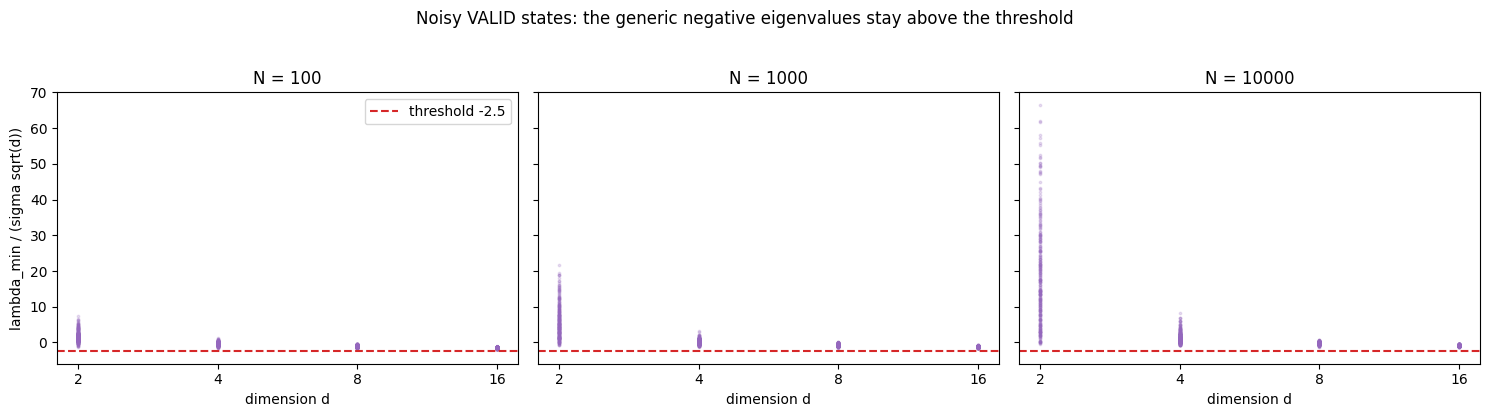

In [2]:
# lambda_min of NOISY VALID states vs the calibrated threshold
dims, budgets, trials = (2, 4, 8, 16), (100, 1000, 10000), 300
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, N in zip(axes, budgets):
    for d in dims:
        scale = sigma_from_shots(N) * np.sqrt(d)
        lam = []
        for i in range(trials):
            noisy = add_tomography_noise(
                random_density_matrix(d, seed=1000 + i), n_shots=N, seed=2000 + i)
            lam.append(np.linalg.eigvalsh((noisy + noisy.conj().T) / 2).min() / scale)
        ax.scatter([d] * trials, lam, s=3, alpha=0.2, color="tab:purple")
    ax.axhline(-2.5, color="tab:red", ls="--", lw=1.5, label="threshold -2.5")
    ax.set_xscale("log", base=2); ax.set_xticks(dims); ax.set_xticklabels(dims)
    ax.set_title(f"N = {N}"); ax.set_xlabel("dimension d")
axes[0].set_ylabel("lambda_min / (sigma sqrt(d))")
axes[0].legend()
fig.suptitle("Noisy VALID states: the generic negative eigenvalues stay above the threshold", y=1.03)
plt.tight_layout(); plt.show()

In [3]:
# Detection of genuinely invalid matrices (noisy mode, N=1000, d=4, magnitude=0.2)
for cause in ("trace", "nonhermitian", "nonpositive"):
    caught = sum(
        not validate_density_matrix(
            add_tomography_noise(
                make_invalid_density(4, cause=cause, magnitude=0.2, seed=i),
                n_shots=1000, seed=5000 + i),
            n_shots=1000).valid
        for i in range(200))
    print(f"{cause:13s}: detected {caught}/200")

# The blind spot, measured honestly: violations below the noise scale
threshold = 2.5 * sigma_from_shots(1000) * np.sqrt(4)
for mag in (0.02, 0.05, 0.10, 0.20):
    caught = sum(
        not validate_density_matrix(
            add_tomography_noise(
                make_invalid_density(4, cause="nonpositive", magnitude=mag, seed=i),
                n_shots=1000, seed=7000 + i),
            n_shots=1000).valid
        for i in range(200))
    print(f"violation {mag:.2f} vs threshold {threshold:.3f}: detected {caught}/200")

trace        : detected 199/200
nonhermitian : detected 200/200
nonpositive  : detected 200/200
violation 0.02 vs threshold 0.079: detected 0/200


violation 0.05 vs threshold 0.079: detected 13/200
violation 0.10 vs threshold 0.079: detected 179/200
violation 0.20 vs threshold 0.079: detected 200/200
